# Customer Retention and Churn Analysis

## Introduction
This project explores which user behaviors and experienced-related factors are most closely associated with churn in subscription business setting.

## Research Question
Which customer behaviors and business-related factors are most strongly associated with churn?

## Hypotheses

H1: Customers with higher product engagement are less likely to churn

H2: Customers generating higher revenue are less likely to churn

H3: Customers with poorer experience (low satisfication, more complaints) are more likely to churn

H4: Pricing changes and discounts are associated with higher churn

H5: Customers with stronger marketing engagement are less likely to churn

## Data Overview

In [110]:
import pandas as pd

In [111]:
customer = pd.read_csv("../data/customer_churn_business_dataset.csv")

In [112]:
print("Total Customers:", customer.shape[0])

Total Customers: 10000


The dataset contains 10,000 customers, which forms the basis of the analysis.

In [113]:
print("Shape:", customer.shape)
print("\nColumns:\n", customer.columns)

Shape: (10000, 32)

Columns:
 Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='str')


In [114]:
customer.info()
customer.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## Data Cleaning

In [115]:
customer["churn"] = customer["churn"].astype(int)

In [116]:
customer["churn"].value_counts()

churn
0    8979
1    1021
Name: count, dtype: int64

In [117]:
customer["churn_label"] = customer["churn"].map({
    0: "Retained",
    1: "Churned"
})

## Visualization Setup
To ensure consistency across all visualizations, a standard color palette and styling configuration was applied.

In [118]:
# Color system
BG_COLOR = "#F5F5F5"
TEXT_COLOR = "#222222"
COLOR_RETAINED = "#2A9D8F"
COLOR_CHURNED = "#E76F51"
COLOR_NEUTRAL = "#7A7A7A"
GRID_COLOR = "#D9D9D9"

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = BG_COLOR
plt.rcParams["axes.facecolor"] = BG_COLOR
plt.rcParams["axes.edgecolor"] = TEXT_COLOR
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams["text.color"] = TEXT_COLOR
plt.rcParams["grid.color"] = GRID_COLOR
plt.rcParams["font.size"] = 12

## Exploratory Data Analysis

/var/folders/9h/81bggl5s1c5d9ckthkpkt8180000gn/T/ipykernel_98344/1320169024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


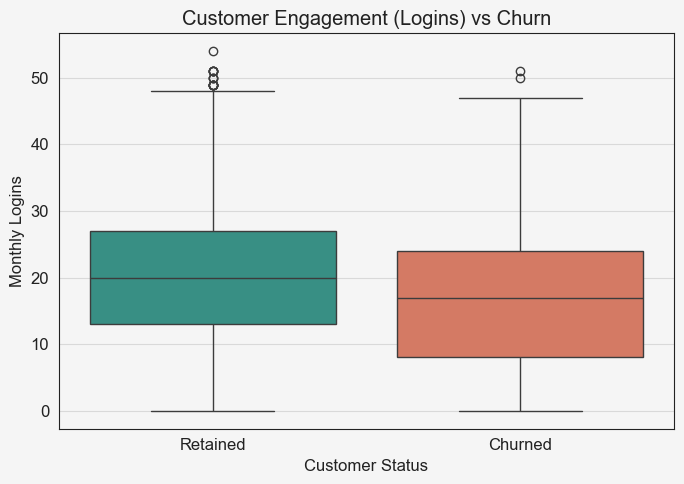

In [120]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_label",
    y="monthly_logins",
    data=customer,
    palette=[COLOR_RETAINED, COLOR_CHURNED]
)

plt.title("Customer Engagement (Logins) vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Logins")

plt.tight_layout()
plt.show()

Customers who were retained generally had slightly higher login activity compared to those who churned. However, the difference between the two groups is not relatively small, and there is a lot of overlap in their behavior. This suggests that login activity alone does not clearly explain why customers churn.

From a business perspective, simply increasing user activity may not be enough to improve retention, and other factors likely play a more important role.

/var/folders/9h/81bggl5s1c5d9ckthkpkt8180000gn/T/ipykernel_98344/2852856678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


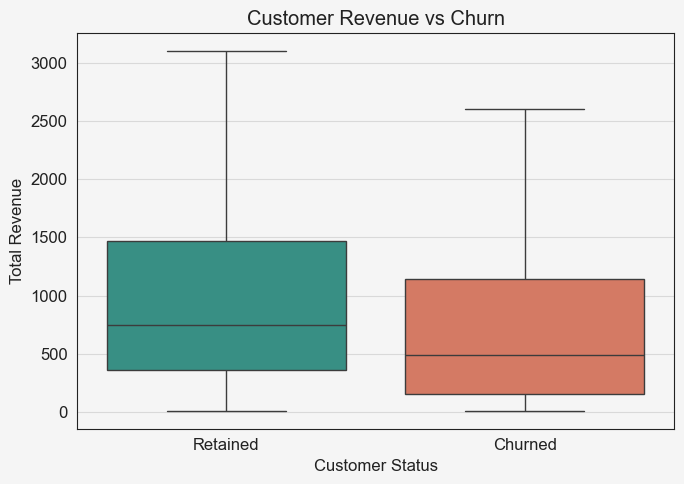

In [121]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_label",
    y="total_revenue",
    data=customer,
    palette=[COLOR_RETAINED, COLOR_CHURNED],
    showfliers=False,
)

plt.title("Customer Revenue vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()


Customers who were retained generally generated higher total revenue compared to those who churned. The difference between the two groups is more noticeable than in the login activity analysis, suggesting that revenue is more closely related to customer retention. While the dataset includes some very high revenue values, the overall pattern remains consistent when focusing on typical customers.

From a business perspective, this suggests that higher-value customers are more likely to stay, and that focusing on customer value and monetization strategies may play an important role in improving retention.

/var/folders/9h/81bggl5s1c5d9ckthkpkt8180000gn/T/ipykernel_98344/1355174686.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


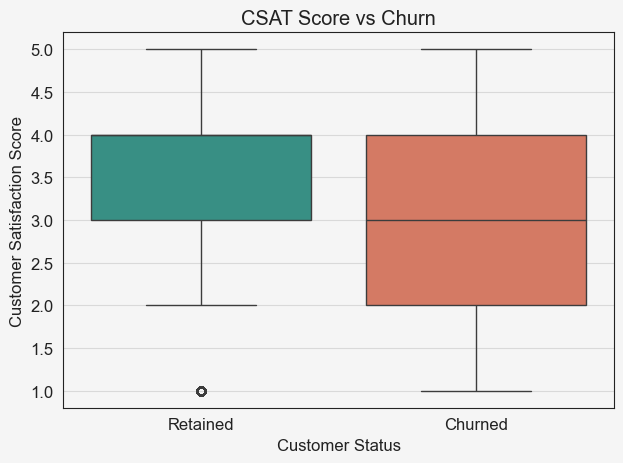

In [122]:
sns.boxplot(
    x="churn_label",
    y="csat_score",
    data=customer,
    palette=[COLOR_RETAINED, COLOR_CHURNED]
)

plt.title("CSAT Score vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Customer Satisfaction Score")

plt.tight_layout()
plt.show()

Customers who were retained generally had higher satisfaction scores compared to those who churned. The difference between the two groups is more noticeable than in both the login activity and revenue results, suggesting that customer satisfaction is more closely related to retention. Customers with lower satisfaction scores appear more likely to churn.

From a business perspective, this highlights the importance of customer experience, suggesting that improving satisfaction levels may be one of the most effective ways to reduce churn.

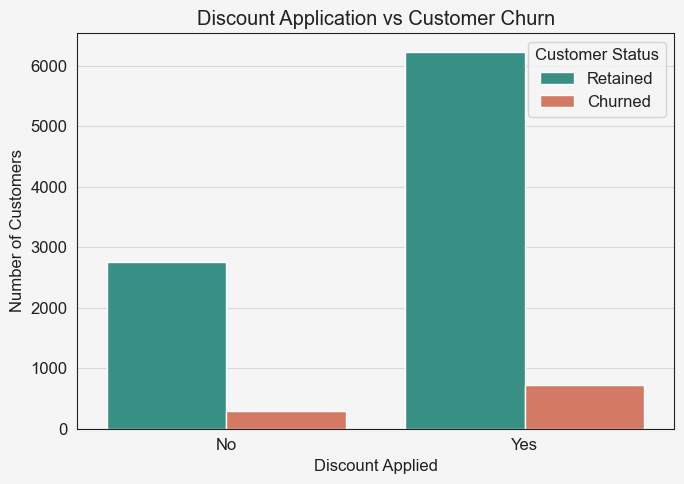

In [123]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="discount_applied",
    hue="churn_label",
    data=customer,
    palette=[COLOR_RETAINED, COLOR_CHURNED]
)

plt.title("Discount Application vs Customer Churn")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Customers")

plt.xticks([0, 1], ["No", "Yes"])
plt.legend(title="Customer Status")

plt.tight_layout()
plt.show()

Customers who received discounts and those who did not show a similar pattern in terms of churn and retention. Although there are more customers without discounts overall, the proportion of churned customers appears comparable across both groups. This suggests that discounts alone don't have a clear relationship with churn in the dataset.

From a business perspective, offering discounts may help with acquistion or short-term engagement, but it does not seem to significantly impact long-term customer retention.

/var/folders/9h/81bggl5s1c5d9ckthkpkt8180000gn/T/ipykernel_98344/2693803789.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


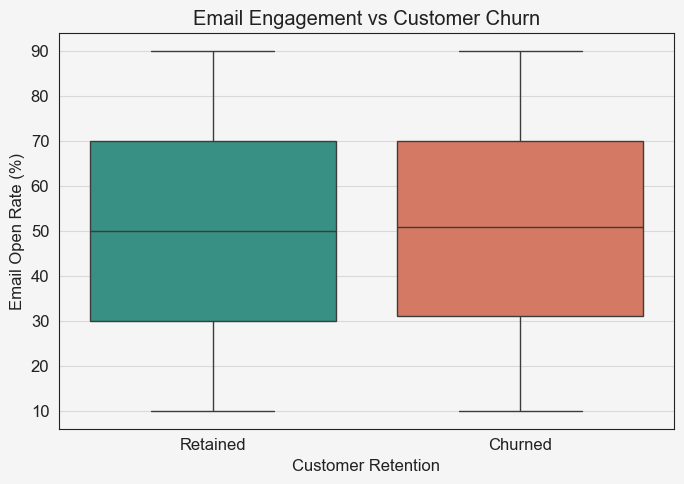

In [124]:
customer["email_open_rate"] = customer["email_open_rate"] * 100
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_label",
    y="email_open_rate",
    data=customer,
    palette=[COLOR_RETAINED, COLOR_CHURNED]
)

plt.title("Email Engagement vs Customer Churn")
plt.xlabel("Customer Retention")
plt.ylabel("Email Open Rate (%)")

plt.tight_layout()
plt.show()

Customers who were retained and those who were churned show very similar levels of email engagement. There is little to noticeable difference between the 2 groups, suggesting that email open rate was does not have clear relationship with churn in this dataset. 

From a business perspective, this indicates that marketing engagement alone may not be a strong driver of customer retention, and other factors such as customer experience or value are likely more important.

## Analysis and Results
The analysis shows that not all customer behaviors have the same impact on churn. Customer satisfaction stands out as the strongest factor. Customers with lower satisfaction scores were much more likely to churn, suggesting that overall experience plays a major role in retention.

Revenue also shows a clear relationship with churn. Customers who generated higher revenue were more likely to be retained, indicating that higher-value customers tend to stay longer.

In contrast, engagement metrics such as login activity showed only a small difference between churned and retained customers. Similarly, discounts and marketing engagement (such as email open rates) did not show a strong or consistent relationship with churn.

Overall, the results suggest that customer experience and value are more important drivers of retention than activity or marketing engagement alone.

## Key Insights
The results suggest that improving customer satisfaction should be a top priority for reducing churn. Since satisfaction shows the strongest relationship with retention, efforts such as better customer support, faster issue resolution, and improved user experience are likely to have the most impact.

Focusing on high-value customers is also important. Customers who generate more revenue tend to stay longer, which suggests that retention strategies should prioritize these segments through personalized engagement or loyalty initiatives.

In contrast, increasing activity or engagement alone may not be enough to reduce churn. Similarly, discounts and marketing efforts do not appear to have a strong influence on retention, indicating that these strategies may be more effective for acquisition rather than long-term retention.

Overall, the findings highlight that customer experience and value should be the primary focus when designing strategies to improve retention.


## Machine Learning
To further support the analysis, a simple logistic regression model was used to predict customer churn based on key variables identified earlier.

In [125]:
features = [
    "csat_score",
    "total_revenue",
    "monthly_logins",
    "support_tickets",
    "avg_resolution_time"
]

In [126]:
print("Features list:", features)
print("\nCustomer columns:\n", customer.columns.tolist())
print("\nMissing from dataframe:", [col for col in features if col not in customer.columns])

Features list: ['csat_score', 'total_revenue', 'monthly_logins', 'support_tickets', 'avg_resolution_time']

Customer columns:
 ['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn', 'churn_label']

Missing from dataframe: []


In [127]:
from sklearn.model_selection import train_test_split

X = customer[features]
y = customer["churn"]

# Fill the missing values with mean
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [128]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [129]:
y_pred = model.predict(X_test)

In [130]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94      1780
           1       0.00      0.00      0.00       220

    accuracy                           0.89      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.79      0.89      0.84      2000



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [131]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,total_revenue,-0.000352
4,avg_resolution_time,-0.001052
3,support_tickets,-0.013957
2,monthly_logins,-0.036057
0,csat_score,-0.559491


## Machine Learning Insights
The model achieved relatively high overall accuracy, but it struggled to correctly identify churned customers due to the imbalance in the dataset.

Since most customers were retained, the model tended to predict retention for most cases, which led to poor performance in detecting churn. This is also reflected in the classification report, where precision and recall for churned customers are very low.

Despite this limitation, the model’s coefficients align with the earlier analysis. Customer satisfaction shows the strongest relationship with churn, while other variables such as login activity and revenue have a smaller impact.

This reinforces the earlier conclusion that customer experience plays a key role in retention, while also highlighting the challenges of predicting churn in imbalanced datasets.